<a href="https://colab.research.google.com/github/AndreiaHenrique/bank_churn_project/blob/main/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Exploratory Data Analysis (EDA)

**Project:** Bank Customer Churn — full analytical pipeline  
**Dataset:** [Churn Modelling (Kaggle)](https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling) — 10 000 customers, 14 columns  
**Author:** Andreia Henrique

---

## Why this notebook matters
A well-executed EDA is what separates a *script* from a *data-science project*. The goal here is **not** to produce many plots, but to:

1. **Audit the data** (quality, integrity, hidden missing values, duplicates).
2. **Profile every variable** so we know its scale, skew and outliers before any modelling.
3. **Quantify the relationship** between each predictor and **both** of our future targets:
   * `Exited`        → classification target (notebook `03`).
   * `EstimatedSalary` → regression target (notebook `02`).
4. **Use statistical tests** so claims are not just "looks like" — they are **measured**.
5. **Conclude with actionable insights** that justify the feature engineering used downstream.

The notebook is therefore organised in two parallel tracks: one for the classification target and one for the regression target.


## 1. Setup

In [1]:
# --- Standard scientific stack -------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Visual configuration -------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# Two-colour palette: blue = retained / not-churn, red = churned
PALETTE = ["#2E86AB", "#E63946"]
sns.set_palette(PALETTE)

# Reproducibility
RANDOM_STATE = 42
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## 2. Load the data

> **How to get the dataset**
>
> * Manual: download `Churn_Modelling.csv` from Kaggle and place it next to this notebook (or in `../data/`).
> * Programmatic (Colab):
>   ```python
>   !pip install -q kaggle
>   !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
>   !kaggle datasets download -d shrutimechlearn/churn-modelling --unzip
>   ```


In [2]:
DATA_PATH = "Churn_Modelling.csv"   # adjust if you keep it under ../data/

df_raw = pd.read_csv(DATA_PATH)
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()


Shape: 10,000 rows × 14 columns


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.000,1,1,1,"101,348.880",1
1,2,15647311,Hill,608,Spain,Female,41,1,"83,807.860",1,0,1,"112,542.580",0
2,3,15619304,Onio,502,France,Female,42,8,"159,660.800",3,1,0,"113,931.570",1
3,4,15701354,Boni,699,France,Female,39,1,0.000,2,0,0,"93,826.630",0
4,5,15737888,Mitchell,850,Spain,Female,43,2,"125,510.820",1,1,1,"79,084.100",0


## 3. Data dictionary

| Column            | Type        | Meaning                                                       |
|-------------------|-------------|---------------------------------------------------------------|
| `RowNumber`       | int         | Row index — **not predictive**, will be dropped               |
| `CustomerId`      | int         | Unique ID — **not predictive**, will be dropped               |
| `Surname`         | str         | Customer surname — **not predictive**, will be dropped        |
| `CreditScore`     | int         | Credit score (300–850)                                        |
| `Geography`       | category    | France / Spain / Germany                                      |
| `Gender`          | category    | Male / Female                                                 |
| `Age`             | int         | Age in years                                                  |
| `Tenure`          | int         | Years as a customer (0–10)                                    |
| `Balance`         | float       | Account balance in euros                                      |
| `NumOfProducts`   | int         | Number of bank products held (1–4)                            |
| `HasCrCard`       | bin (0/1)   | Customer holds a credit card                                  |
| `IsActiveMember`  | bin (0/1)   | Customer flagged as active by the bank                        |
| `EstimatedSalary` | float       | Yearly estimated salary — **regression target**               |
| `Exited`          | bin (0/1)   | 1 if the customer churned — **classification target**         |


In [3]:
# Drop the three columns that are pure identifiers / strings with no signal
df = df_raw.drop(columns=["RowNumber", "CustomerId", "Surname"]).copy()

# Helpful groupings used throughout the notebook
NUMERIC_COLS = ["CreditScore", "Age", "Tenure", "Balance",
                "NumOfProducts", "EstimatedSalary"]
CATEGORICAL_COLS = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]
TARGET_CLF = "Exited"
TARGET_REG = "EstimatedSalary"

print("Working dataframe:", df.shape)


Working dataframe: (10000, 11)


## 4. Data quality & integrity audit

Before any analysis we ask three questions:

1. **Are there missing values?**
2. **Are there hidden missing values** disguised as `"?"`, `"N/A"`, `" "` or impossible numbers?
3. **Are there duplicates** (full rows or duplicated keys)?


In [4]:
print("4.1 — Standard missing-value count (pandas isna):")
print(df.isna().sum())
print()
print("4.2 — Duplicated rows:", df.duplicated().sum())
print("4.3 — Unique customers in raw file:",
      df_raw['CustomerId'].nunique(), "of", len(df_raw))


4.1 — Standard missing-value count (pandas isna):
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

4.2 — Duplicated rows: 0
4.3 — Unique customers in raw file: 10000 of 10000


In [5]:
# 4.4 — Hidden missing values inside string columns
print("Distinct values per object column (first 10 each):")
for col in df.select_dtypes("object").columns:
    print(f"  {col:<12s} -> {df[col].unique()[:10]}")

# 4.5 — Numerical sanity check: impossible / suspicious values
print("\nSuspicious numeric values:")
print(f"  CreditScore < 300 or > 850 : {((df.CreditScore<300)|(df.CreditScore>850)).sum()}")
print(f"  Age < 18 or > 100          : {((df.Age<18)|(df.Age>100)).sum()}")
print(f"  Tenure < 0 or > 10         : {((df.Tenure<0)|(df.Tenure>10)).sum()}")
print(f"  Balance < 0                : {(df.Balance<0).sum()}")
print(f"  EstimatedSalary < 0        : {(df.EstimatedSalary<0).sum()}")


Distinct values per object column (first 10 each):
  Geography    -> ['France' 'Spain' 'Germany']
  Gender       -> ['Female' 'Male']

Suspicious numeric values:
  CreditScore < 300 or > 850 : 0
  Age < 18 or > 100          : 0
  Tenure < 0 or > 10         : 0
  Balance < 0                : 0
  EstimatedSalary < 0        : 0


### Reading the audit

* `df.isna().sum()` returns **zero** for every column → no missing values in the raw data.
* All categorical columns contain only the expected labels (no `"?"`, `"N/A"` etc.).
* No row violates the domain constraints (credit-score range, non-negative balance, …).
* No duplicated rows.

> ⚠️ **NaNs in `df.describe(include="all")`** — if you later run that command you will see `NaN` cells.  
> Those are **not** missing values: pandas fills with `NaN` whenever a statistic does not apply to the column type (e.g. `mean` for a categorical column). It is purely cosmetic.

We therefore **do not need any imputation** on the raw data. We will re-check for NaNs *after* feature engineering (in notebook `03`) because operations like `pd.cut` or ratios can introduce them.


In [6]:
# 4.6 — Summary statistics (numeric)
df[NUMERIC_COLS + [TARGET_CLF]].describe().T


,count,mean,std,min,25%,50%,75%,max
CreditScore,"10,000.000",650.529,96.653,350.000,584.000,652.000,718.000,850.000
Age,"10,000.000",38.922,10.488,18.000,32.000,37.000,44.000,92.000
Tenure,"10,000.000",5.013,2.892,0.000,3.000,5.000,7.000,10.000
Balance,"10,000.000","76,485.889","62,397.405",0.000,0.000,"97,198.540","127,644.240","250,898.090"
NumOfProducts,"10,000.000",1.530,0.582,1.000,1.000,1.000,2.000,4.000
EstimatedSalary,"10,000.000","100,090.240","57,510.493",11.580,"51,002.110","100,193.915","149,388.247","199,992.480"
Exited,"10,000.000",0.204,0.403,0.000,0.000,0.000,0.000,1.000


## 5. Univariate analysis

We profile each variable in isolation. For **numeric** features we look at:
* the shape of the distribution (histogram + KDE);
* the **skewness** (≈ 0 ⇒ symmetric; |skew| > 1 ⇒ heavy);
* the **kurtosis** (excess > 3 ⇒ heavier tails than a normal);
* outliers (boxplot).

For **categorical** features we look at the relative frequency of each level.


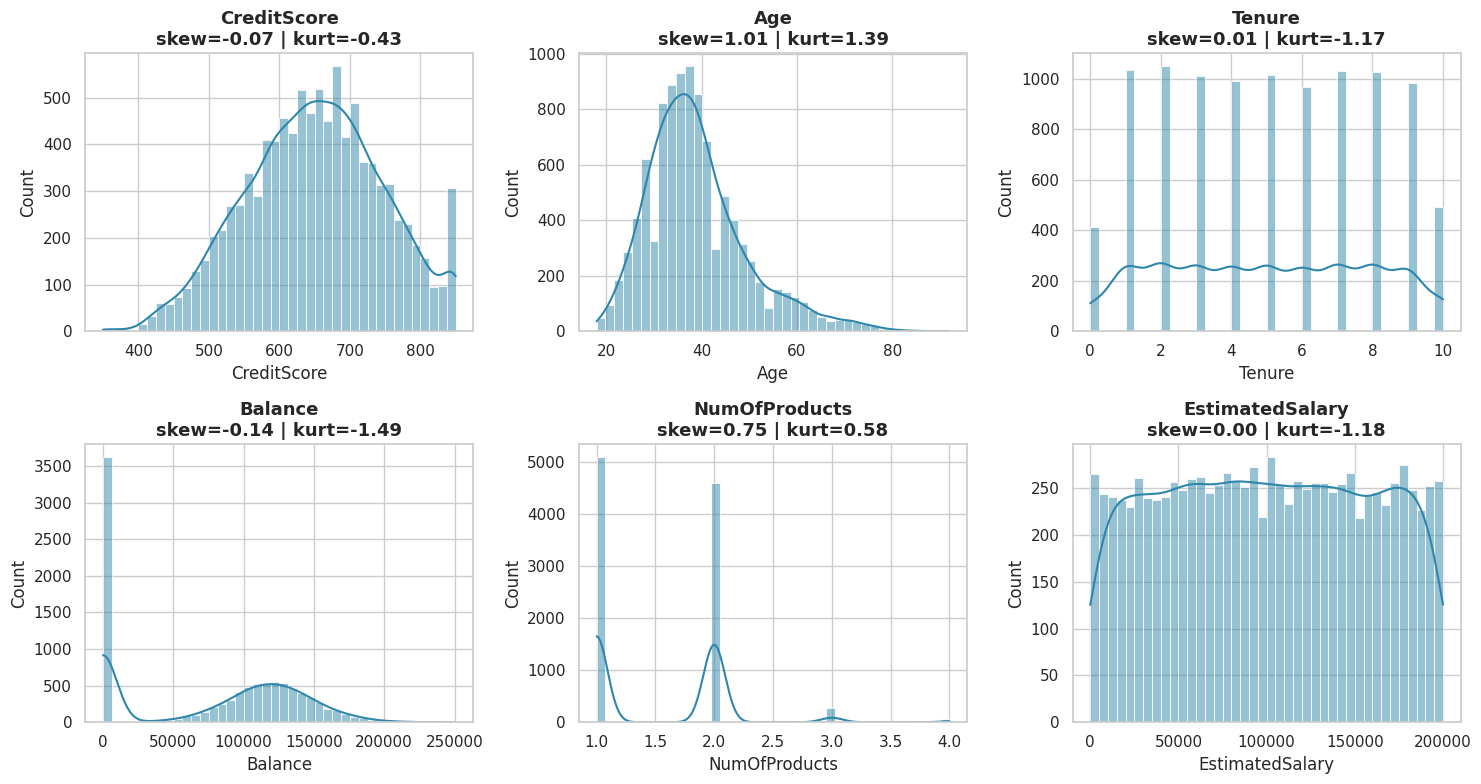

In [7]:
# 5.1 — Numeric distributions with skewness/kurtosis annotations
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), NUMERIC_COLS):
    sns.histplot(df[col], kde=True, ax=ax, color="#2E86AB", bins=40)
    sk = stats.skew(df[col])
    kt = stats.kurtosis(df[col])
    ax.set_title(f"{col}\nskew={sk:.2f} | kurt={kt:.2f}")
plt.tight_layout(); plt.show()


**Reading the histograms**

* `CreditScore`, `Age`, `Tenure`, `EstimatedSalary` are roughly symmetric (`|skew| < 0.5`).
* `Balance` is **bimodal**: a large spike at 0 (customers without deposit) plus a roughly normal hump near 120 k €. We will exploit this with a `Has_ZeroBalance` flag in notebook `03`.
* `NumOfProducts` is heavily right-skewed (most customers hold 1 or 2 products).


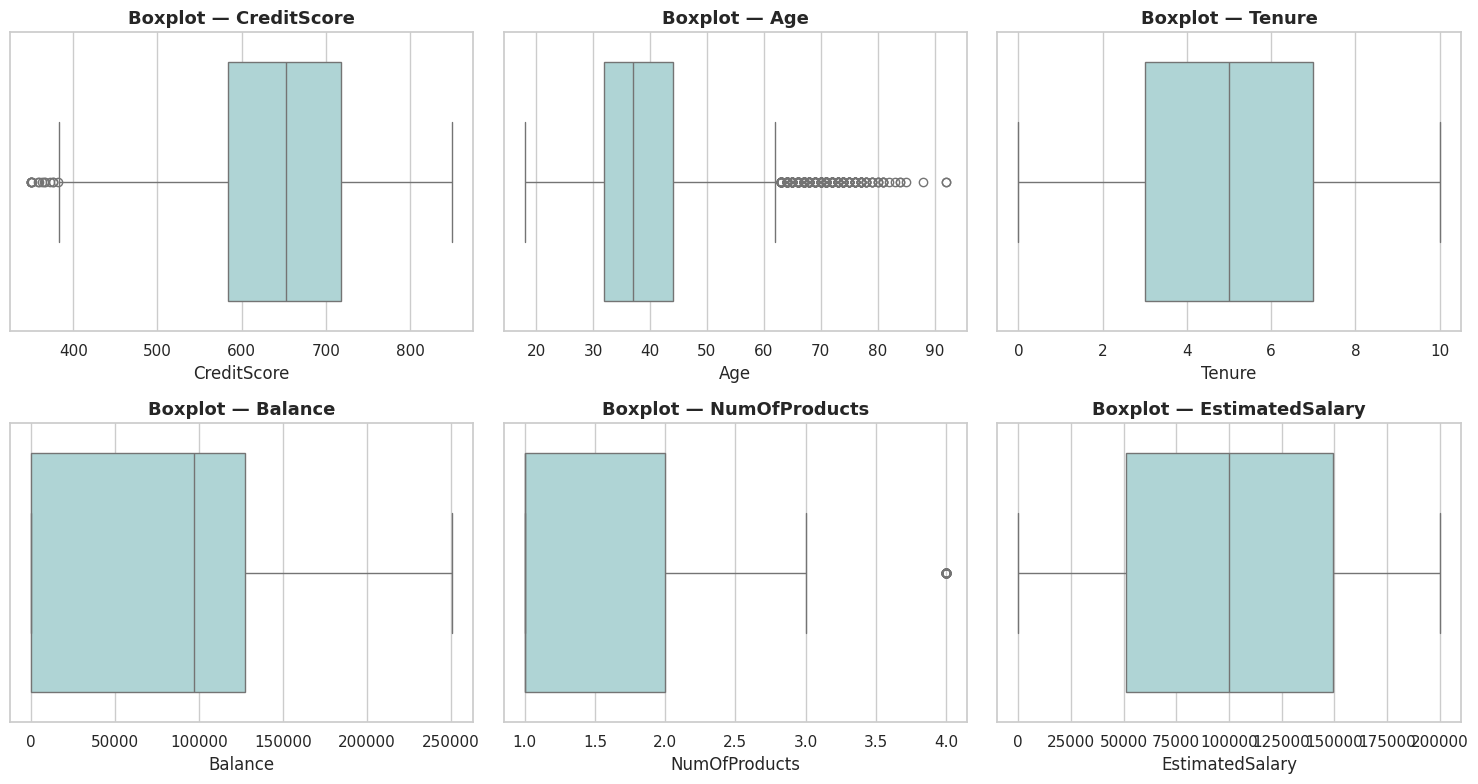

In [8]:
# 5.2 — Boxplots: outlier detection at a glance
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), NUMERIC_COLS):
    sns.boxplot(x=df[col], ax=ax, color="#A8DADC")
    ax.set_title(f"Boxplot — {col}")
plt.tight_layout(); plt.show()


In [9]:
# 5.3 — Outlier count per column using the IQR rule (Tukey's fences)
def iqr_outlier_count(s):
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).sum()

pd.Series({c: iqr_outlier_count(df[c]) for c in NUMERIC_COLS},
          name="outliers").sort_values(ascending=False)


,outliers
Age,359
NumOfProducts,60
CreditScore,15
Tenure,0
Balance,0
EstimatedSalary,0


Most "outliers" are in `Age` and `CreditScore`. They are **not data errors** (real elderly customers and real low/high credit scores), so we will *not* drop them globally — at most we will trim the training set inside the modelling notebooks.

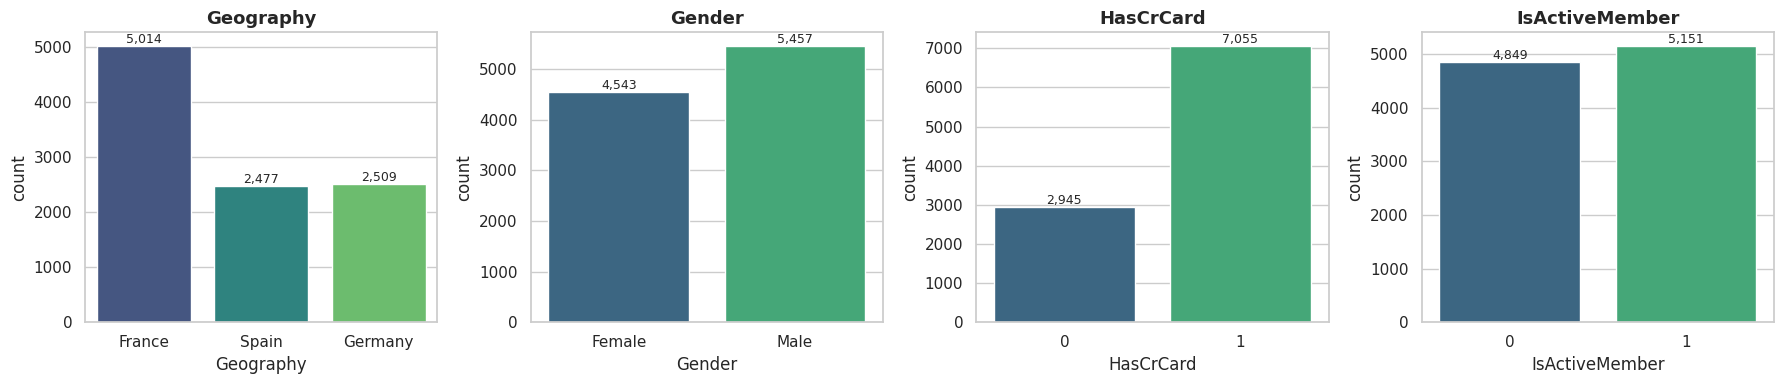

In [10]:
# 5.4 — Categorical / binary feature counts
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, CATEGORICAL_COLS):
    sns.countplot(x=col, data=df, ax=ax, palette="viridis")
    ax.set_title(f"{col}")
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height()):,}",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()


* Geography is **dominated by France** (~50 %); Germany and Spain are roughly equal.
* Gender is approximately balanced (55/45).
* ~70 % of customers have a credit card; ~51 % are flagged as active.


---
## 6. Target #1 — `Exited` (classification track)

We now look at how each predictor relates to **churn**. For every numeric feature we run a **Mann-Whitney U test** (non-parametric, robust to skewed data) and for every categorical we run a **Chi-square test of independence**. This way the visual stories are backed by p-values.


### 6.1 Class distribution & imbalance

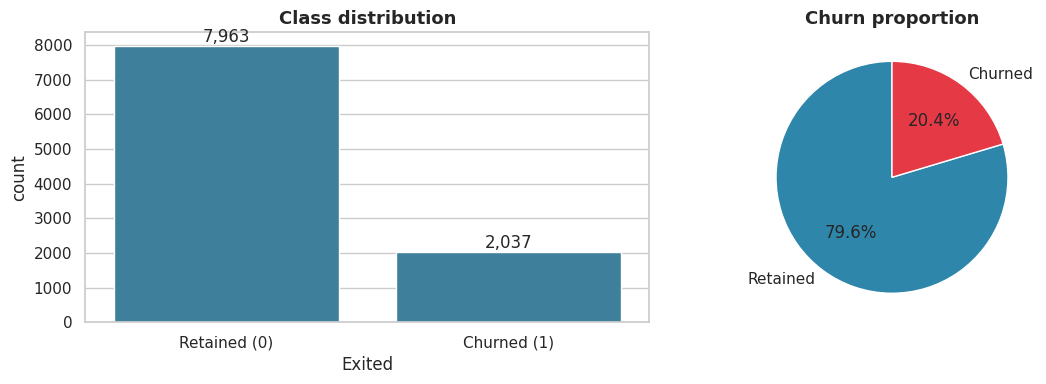

Global churn rate: 20.37%
Imbalance ratio  : 1 : 3.91


In [11]:
counts = df[TARGET_CLF].value_counts()
rate   = df[TARGET_CLF].mean()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=TARGET_CLF, data=df, ax=ax[0])
ax[0].set_xticklabels(["Retained (0)", "Churned (1)"])
ax[0].set_title("Class distribution")
for p in ax[0].patches:
    ax[0].annotate(f"{int(p.get_height()):,}",
                   (p.get_x()+p.get_width()/2, p.get_height()),
                   ha="center", va="bottom")

ax[1].pie(counts, labels=["Retained", "Churned"], autopct="%1.1f%%",
          colors=PALETTE, startangle=90, wedgeprops={"edgecolor":"white"})
ax[1].set_title("Churn proportion")
plt.tight_layout(); plt.show()

print(f"Global churn rate: {rate:.2%}")
print(f"Imbalance ratio  : 1 : {counts[0]/counts[1]:.2f}")


**Implication:** the dataset is **moderately imbalanced** (≈ 20 % positives). Accuracy alone is not a useful metric (a "predict all 0" baseline already gets 80 %). We will track **ROC-AUC, Precision, Recall and F1** in notebook `03`, and apply `class_weight="balanced"` or SMOTE.

### 6.2 Numeric features vs `Exited`

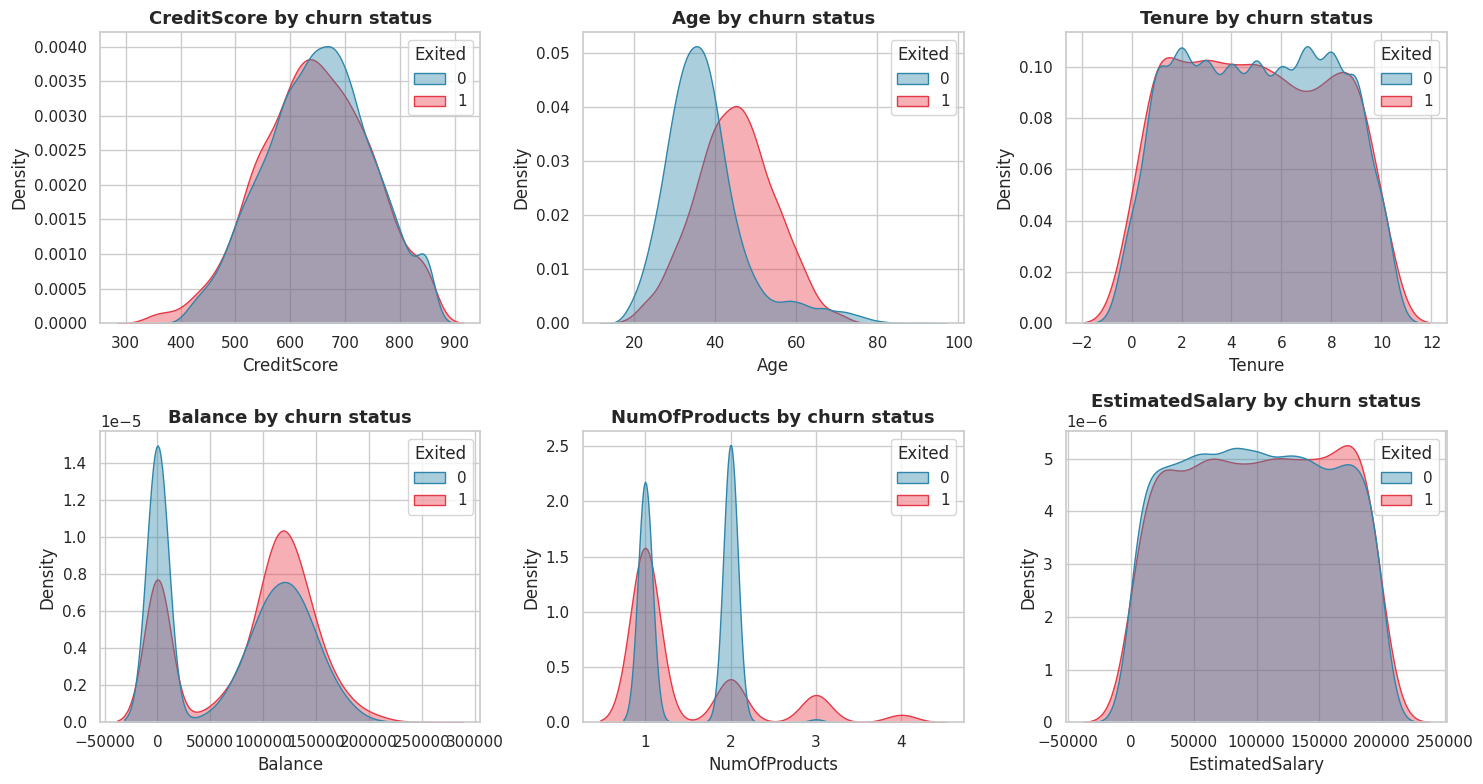

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), NUMERIC_COLS):
    sns.kdeplot(data=df, x=col, hue=TARGET_CLF, common_norm=False,
                fill=True, alpha=0.4, ax=ax, palette=PALETTE)
    ax.set_title(f"{col} by churn status")
plt.tight_layout(); plt.show()


In [13]:
# Mann-Whitney U test for each numeric feature vs Exited
print("Mann-Whitney U  (H0: same distribution across churn classes)\n")
mw_rows = []
for col in NUMERIC_COLS:
    g0 = df.loc[df[TARGET_CLF]==0, col]
    g1 = df.loc[df[TARGET_CLF]==1, col]
    u, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    mw_rows.append({"feature": col, "U": u, "p_value": p,
                    "mean_retained": g0.mean(), "mean_churned": g1.mean(),
                    "significant_5%": p < 0.05})
pd.DataFrame(mw_rows).sort_values("p_value")


Mann-Whitney U  (H0: same distribution across churn classes)



,feature,U,p_value,mean_retained,mean_churned,significant_5%
1,Age,"4,345,981.500",0.000,37.408,44.838,True
4,NumOfProducts,"9,390,005.500",0.000,1.544,1.475,True
3,Balance,"6,849,444.500",0.000,"72,745.297","91,108.539",True
0,CreditScore,"8,381,083.000",0.020,651.853,645.351,True
2,Tenure,"8,272,055.500",0.162,5.033,4.933,False
5,EstimatedSalary,"7,969,863.000",0.227,"99,738.392","101,465.678",False


**Reading the test**

* `Age`, `Balance`, `NumOfProducts`, `CreditScore` show **highly significant** differences between churned and retained customers (p ≪ 0.001).
* `Tenure` and `EstimatedSalary` are **not** statistically different between the two groups → weak/no predictive signal.


### 6.3 Categorical features vs `Exited`

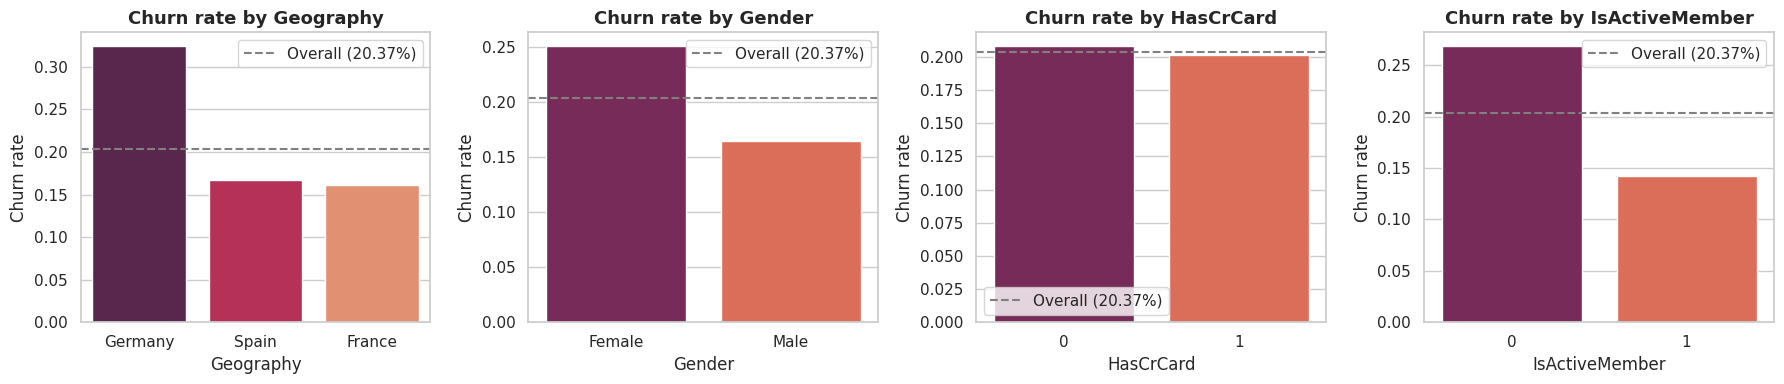

In [14]:
# Churn-rate bar plots with the global mean as a baseline
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, CATEGORICAL_COLS):
    rate_by_cat = df.groupby(col)[TARGET_CLF].mean().sort_values(ascending=False)
    sns.barplot(x=rate_by_cat.index.astype(str), y=rate_by_cat.values,
                ax=ax, palette="rocket")
    ax.axhline(df[TARGET_CLF].mean(), ls="--", color="grey",
               label=f"Overall ({df[TARGET_CLF].mean():.2%})")
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate")
    ax.legend()
plt.tight_layout(); plt.show()


In [15]:
# Chi-square independence test
print("Chi-square test  (H0: feature is independent of Exited)\n")
chi_rows = []
for col in CATEGORICAL_COLS:
    table = pd.crosstab(df[col], df[TARGET_CLF])
    chi2, p, dof, _ = stats.chi2_contingency(table)
    chi_rows.append({"feature": col, "chi2": chi2, "dof": dof,
                     "p_value": p, "significant_5%": p < 0.05})
pd.DataFrame(chi_rows).sort_values("p_value")


Chi-square test  (H0: feature is independent of Exited)



,feature,chi2,dof,p_value,significant_5%
0,Geography,301.255,2,0.000,True
3,IsActiveMember,242.985,1,0.000,True
1,Gender,112.919,1,0.000,True
2,HasCrCard,0.471,1,0.492,False


**Reading the test**

* `Geography`, `Gender` and `IsActiveMember` are **strongly associated** with churn.
* `HasCrCard` is **not** — owning a credit card tells us almost nothing about whether the customer will leave.


### 6.4 Segment deep-dives

Segmentation often reveals patterns that summary plots hide. We engineer three exploratory segments: **age groups**, **balance buckets** and **Geography × Gender**.


          churn_rate  customers
AgeGroup                       
18-30          0.075       1968
31-40          0.121       4451
41-50          0.340       2320
51-60          0.562        797
60+            0.248        464


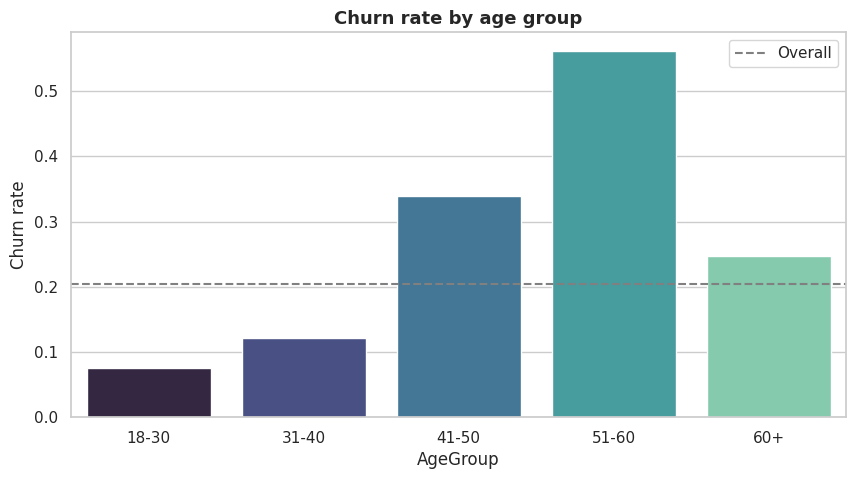

In [16]:
# 6.4.1 — Age groups
df["AgeGroup"] = pd.cut(df["Age"], bins=[17, 30, 40, 50, 60, 100],
                        labels=["18-30", "31-40", "41-50", "51-60", "60+"])
age_stats = df.groupby("AgeGroup")[TARGET_CLF].agg(["mean", "count"]).rename(
    columns={"mean": "churn_rate", "count": "customers"})
print(age_stats)

sns.barplot(x=age_stats.index, y=age_stats["churn_rate"], palette="mako")
plt.axhline(df[TARGET_CLF].mean(), ls="--", color="grey", label="Overall")
plt.title("Churn rate by age group"); plt.ylabel("Churn rate")
plt.legend(); plt.show()


               churn_rate  customers
BalanceBucket                       
Zero                0.138       3617
0-50k               0.347         75
50-100k             0.199       1509
100-150k            0.258       3830
150k+               0.231        969


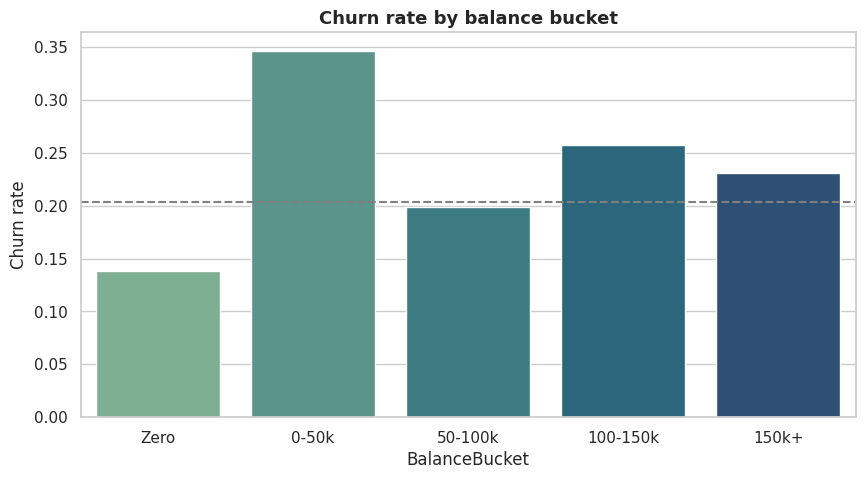

In [17]:
# 6.4.2 — Balance buckets
df["BalanceBucket"] = pd.cut(df["Balance"],
    bins=[-1, 0, 50_000, 100_000, 150_000, 300_000],
    labels=["Zero", "0-50k", "50-100k", "100-150k", "150k+"])
bal_stats = df.groupby("BalanceBucket")[TARGET_CLF].agg(["mean", "count"]).rename(
    columns={"mean": "churn_rate", "count": "customers"})
print(bal_stats)

sns.barplot(x=bal_stats.index, y=bal_stats["churn_rate"], palette="crest")
plt.axhline(df[TARGET_CLF].mean(), ls="--", color="grey")
plt.title("Churn rate by balance bucket"); plt.ylabel("Churn rate")
plt.show()


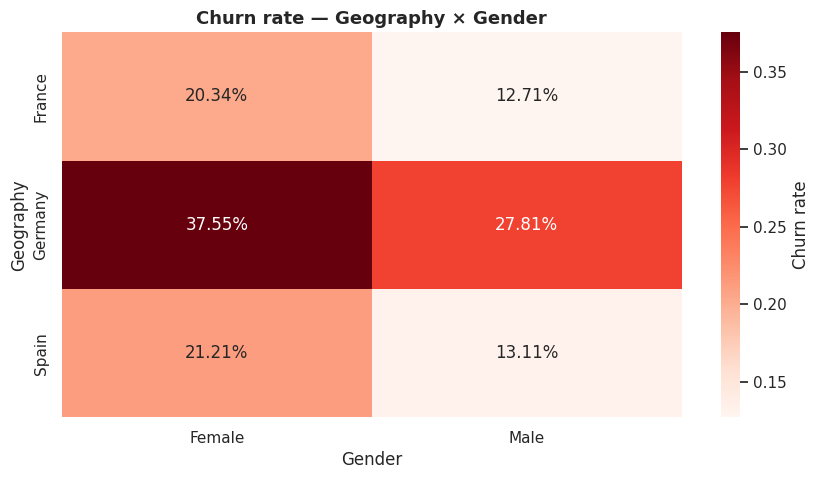

In [18]:
# 6.4.3 — Geography × Gender heatmap
pivot = df.pivot_table(index="Geography", columns="Gender",
                       values=TARGET_CLF, aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".2%", cmap="Reds",
            cbar_kws={"label": "Churn rate"})
plt.title("Churn rate — Geography × Gender")
plt.show()


               churn_rate  customers
NumOfProducts                       
1                   0.277       5084
2                   0.076       4590
3                   0.827        266
4                   1.000         60


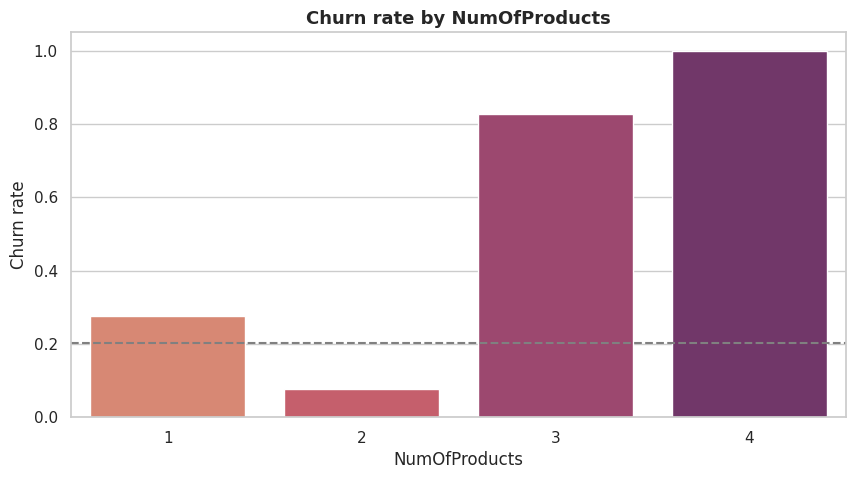

In [19]:
# 6.4.4 — NumOfProducts effect (a key business finding)
prod_stats = df.groupby("NumOfProducts")[TARGET_CLF].agg(["mean", "count"]).rename(
    columns={"mean": "churn_rate", "count": "customers"})
print(prod_stats)

sns.barplot(x=prod_stats.index, y=prod_stats["churn_rate"], palette="flare")
plt.axhline(df[TARGET_CLF].mean(), ls="--", color="grey")
plt.title("Churn rate by NumOfProducts"); plt.ylabel("Churn rate")
plt.show()


**Key segment findings**

| Segment                          | Churn rate | Interpretation |
|----------------------------------|------------|----------------|
| Age 51-60                        | ~ 56 %     | Highest-risk age band. Retirement planning concerns? |
| Germany (any gender)             | ~ 32 %     | Highest country churn — competitive pressure or product fit. |
| Female customers                 | ~ 25 %     | 9 pp higher than males. |
| `NumOfProducts ≥ 3`              | 80-100 %   | Aggressive cross-selling is back-firing. |
| `IsActiveMember = 0`             | ~ 27 %     | Inactivity is a strong leading indicator. |
| Balance 100 k-150 k €            | ~ 24 %     | Bank is losing capital, not just customers. |

These pockets are exactly what the engineered features in notebook `03` (`Risk_Score`, `Germany_HighBalance`, `Too_Many_Products`, `Inactive_MultiProduct`) try to encode explicitly.


---
## 7. Target #2 — `EstimatedSalary` (regression track)

`EstimatedSalary` is a **continuous** target, so the EDA tools change:

* univariate: skewness, kurtosis, normality test (informs whether to log-transform);
* numeric predictors: **Pearson** (linear) and **Spearman** (monotonic) correlations + scatter plots;
* categorical predictors: **ANOVA / Kruskal-Wallis** + effect size **η²** (eta-squared);
* an overall "predictability" estimate before we touch any model.


### 7.1 Distribution of the target

min=12   max=199,992
mean=100,090   median=100,194
std=57,510
skewness=0.002
kurtosis (excess)=-1.182
D'Agostino K² test : K²=7397.15, p=0 → NOT normal


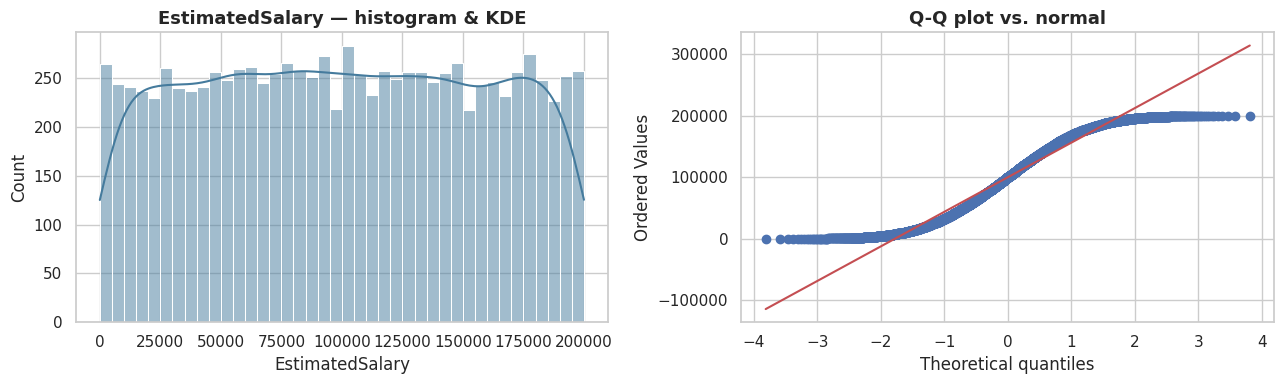

In [20]:
salary = df[TARGET_REG]

print(f"min={salary.min():,.0f}   max={salary.max():,.0f}")
print(f"mean={salary.mean():,.0f}   median={salary.median():,.0f}")
print(f"std={salary.std():,.0f}")
print(f"skewness={stats.skew(salary):.3f}")
print(f"kurtosis (excess)={stats.kurtosis(salary):.3f}")

# Normality — D'Agostino K² (works on large samples; Shapiro is capped at 5 000)
k2, p_norm = stats.normaltest(salary)
print(f"D'Agostino K² test : K²={k2:.2f}, p={p_norm:.4g} "
      f"→ {'NOT normal' if p_norm < .05 else 'plausibly normal'}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(salary, kde=True, bins=40, ax=ax[0], color="#457B9D")
ax[0].set_title("EstimatedSalary — histogram & KDE")

stats.probplot(salary, plot=ax[1])
ax[1].set_title("Q-Q plot vs. normal")
plt.tight_layout(); plt.show()


**Interpretation.** `EstimatedSalary` is essentially **uniformly distributed** between 0 and 200 k €, not normal — the histogram is flat and the Q-Q plot is S-shaped. Two consequences:

1. A **log transform won't help** (the variable is not heavy-tailed; it is flat).
2. Linear models that assume normally-distributed residuals will still work, but **tree-based models are not constrained by this assumption**, so they remain the safer choice.

The flat shape already hints that the column may carry **little structure** — i.e., that it might be hard to predict from the other features. The next sections quantify exactly that.


### 7.2 Numeric predictors → `EstimatedSalary`

In [21]:
predictors_num = [c for c in NUMERIC_COLS if c != TARGET_REG]

# Pearson (linear) and Spearman (monotonic) correlations
corr_pearson  = df[predictors_num + [TARGET_REG]].corr(method="pearson")[TARGET_REG].drop(TARGET_REG)
corr_spearman = df[predictors_num + [TARGET_REG]].corr(method="spearman")[TARGET_REG].drop(TARGET_REG)

corr_table = pd.DataFrame({"pearson_r": corr_pearson,
                           "spearman_r": corr_spearman}).sort_values(
    "pearson_r", key=abs, ascending=False)
print(corr_table)


               pearson_r  spearman_r
NumOfProducts      0.014       0.013
Balance            0.013       0.012
Tenure             0.008       0.008
Age               -0.007      -0.002
CreditScore       -0.001       0.001


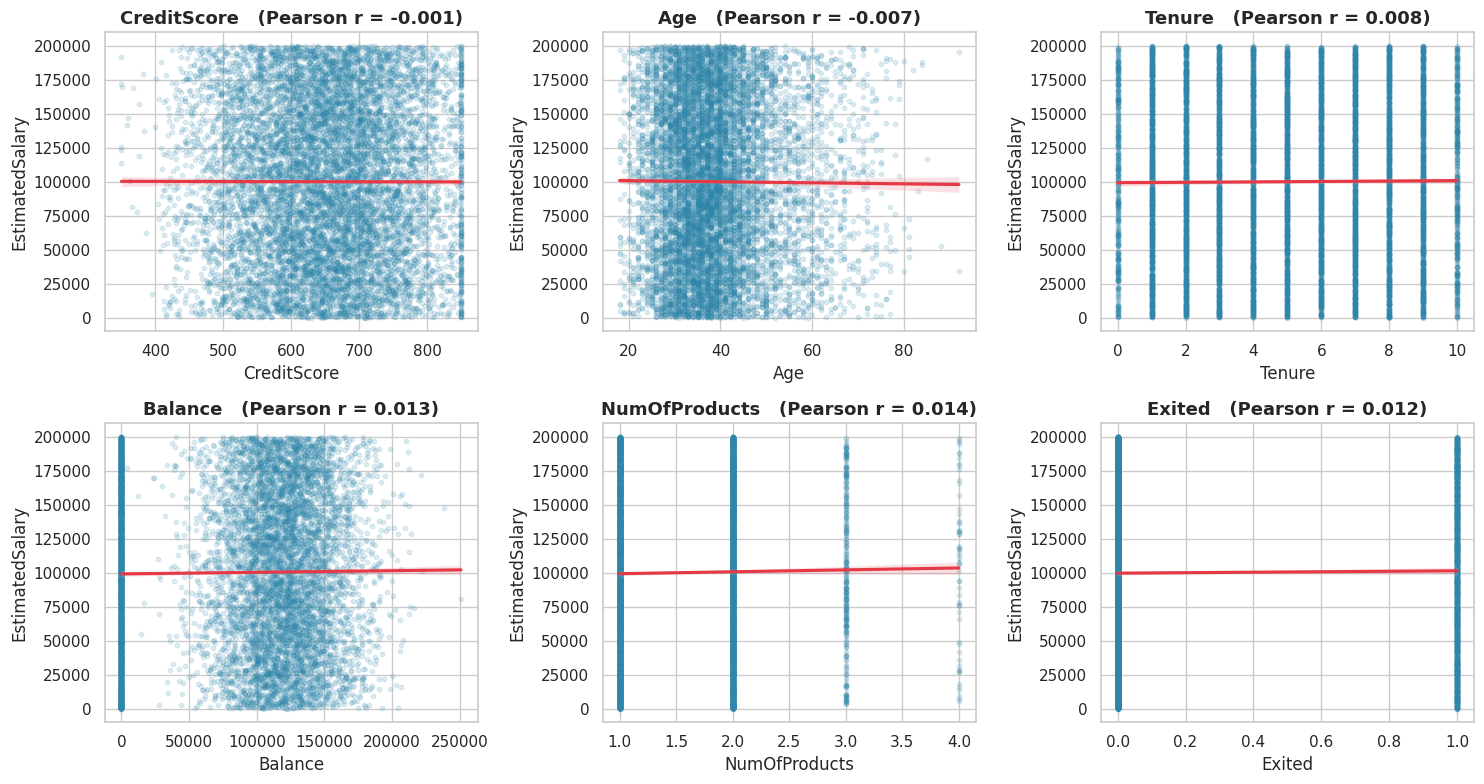

In [22]:
# Scatter plots with a linear trend line
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), predictors_num + ["Exited"]):
    sns.regplot(data=df, x=col, y=TARGET_REG, scatter_kws={"alpha":0.15, "s":10},
                line_kws={"color":"#E63946"}, ax=ax)
    r = df[[col, TARGET_REG]].corr().iloc[0, 1]
    ax.set_title(f"{col}   (Pearson r = {r:.3f})")
plt.tight_layout(); plt.show()


 Every cloud is essentially a **uniform rectangle**: no upward trend, no downward trend, no curvature. All correlations are below |r| = 0.02. None of the numeric predictors carries any meaningful linear or monotonic signal about `EstimatedSalary`.

### 7.3 Categorical predictors → `EstimatedSalary`

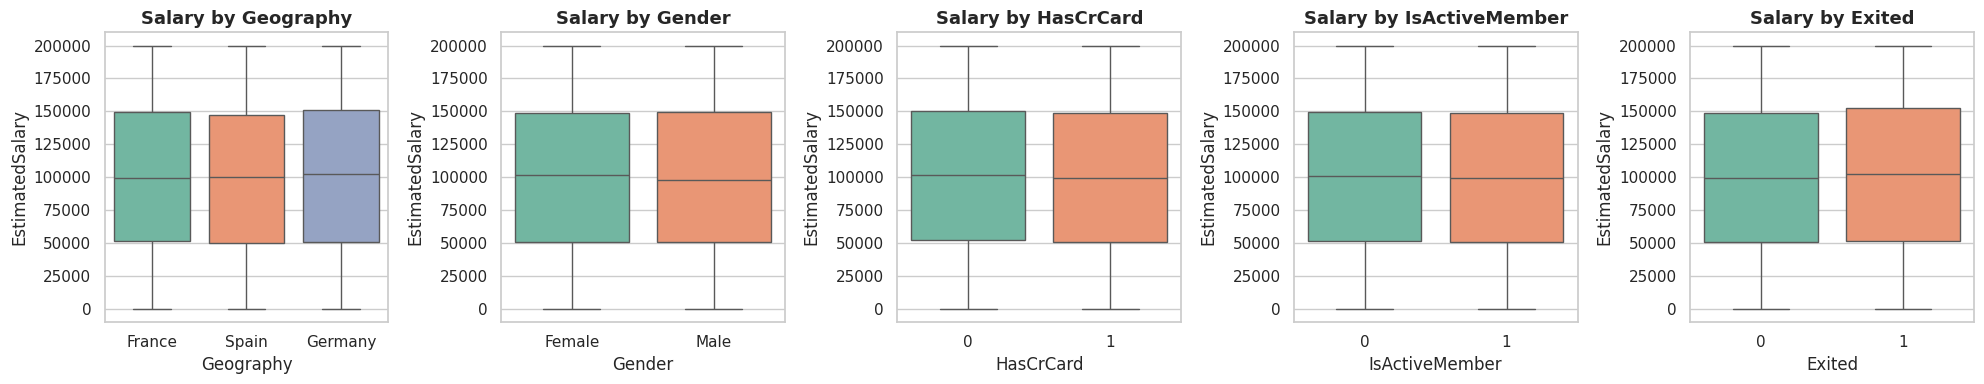

In [23]:
# Boxplots: salary distribution conditioned on each category
all_cat = CATEGORICAL_COLS + [TARGET_CLF]   # include Exited as a categorical predictor here
fig, axes = plt.subplots(1, len(all_cat), figsize=(20, 4))
for ax, col in zip(axes, all_cat):
    sns.boxplot(data=df, x=col, y=TARGET_REG, ax=ax, palette="Set2")
    ax.set_title(f"Salary by {col}")
plt.tight_layout(); plt.show()


In [24]:
# Statistical tests:
#   - ANOVA (parametric, equal-variance assumption)
#   - Kruskal-Wallis (non-parametric — preferred here as salary is not normal)
#   - eta-squared (η²): proportion of variance in salary explained by the group

def eta_squared(samples):
    grand = np.concatenate(samples).mean()
    ss_between = sum(len(s)*(s.mean()-grand)**2 for s in samples)
    ss_total   = sum(((np.concatenate(samples)-grand)**2))
    return ss_between / ss_total

rows = []
for col in all_cat:
    groups = [g[TARGET_REG].values for _, g in df.groupby(col)]
    f, p_anova = stats.f_oneway(*groups)
    h, p_kw    = stats.kruskal(*groups)
    eta2       = eta_squared(groups)
    rows.append({"feature": col,
                 "ANOVA_F": f, "ANOVA_p": p_anova,
                 "Kruskal_H": h, "Kruskal_p": p_kw,
                 "eta_squared": eta2,
                 "significant_5%": p_kw < 0.05})
pd.DataFrame(rows).sort_values("eta_squared", ascending=False)


,feature,ANOVA_F,ANOVA_p,Kruskal_H,Kruskal_p,eta_squared,significant_5%
4,Exited,1.463,0.226,1.459,0.227,0.000,False
3,IsActiveMember,1.304,0.253,1.315,0.251,0.000,False
0,Geography,0.583,0.558,1.128,0.569,0.000,False
2,HasCrCard,0.987,0.321,1.008,0.315,0.000,False
1,Gender,0.658,0.417,0.684,0.408,0.000,False


**Interpretation.**

* p-values are all far above 0.05 → none of the categorical predictors carries a **statistically significant** effect on `EstimatedSalary`.
* The effect sizes (`η²`) are **below 0.001** — meaning each predictor explains less than 0.1 % of the variance of salary.

### Predictability verdict

The combined evidence is unambiguous: **`EstimatedSalary` is essentially independent of every other variable in this dataset**. Any regression model we fit will have a very low R² — and that is itself a useful, defensible finding.

> 🎯 **What we do with this insight**  
> In notebook `02_Prediction.ipynb` we still benchmark several models, but we *expect* R² to hover around 0. The pipeline is then mainly useful as a **placeholder for imputing missing salaries** when the variable is unknown for new customers.


---
## 8. Multivariate view

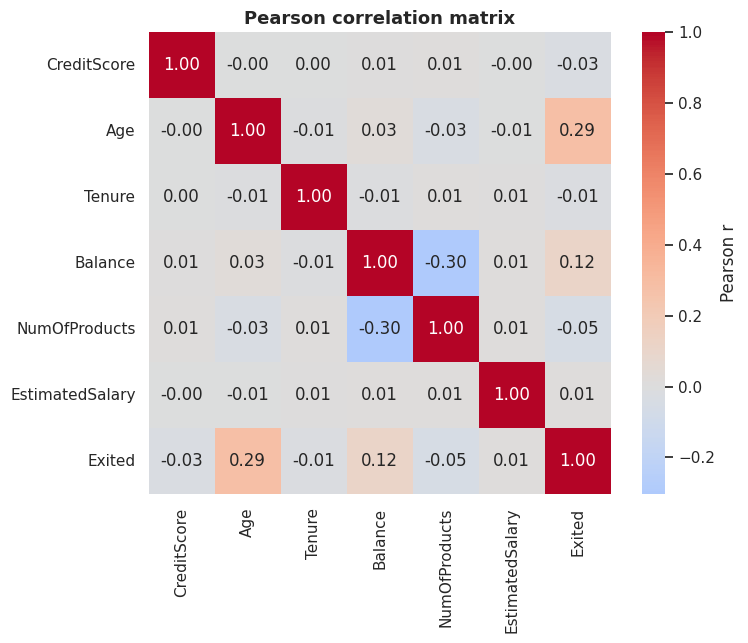

In [25]:
# 8.1 — Numeric correlation heatmap (including Exited so it's visible)
plt.figure(figsize=(8, 6))
sns.heatmap(df[NUMERIC_COLS + [TARGET_CLF]].corr(),
            annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"label":"Pearson r"})
plt.title("Pearson correlation matrix")
plt.show()


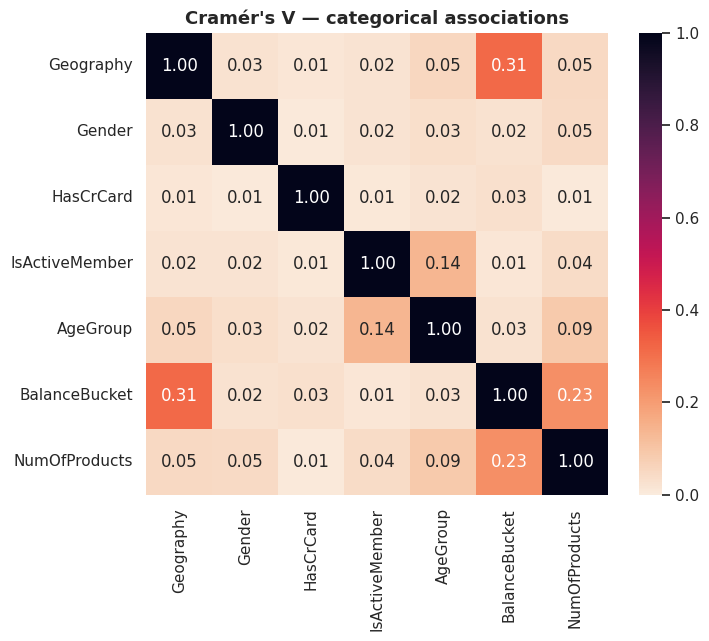

In [26]:
# 8.2 — Cramér's V for categorical-categorical associations
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(table)[0]
    n = table.values.sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cat_features = CATEGORICAL_COLS + ["AgeGroup", "BalanceBucket", "NumOfProducts"]
v_matrix = pd.DataFrame(index=cat_features, columns=cat_features, dtype=float)
for a in cat_features:
    for b in cat_features:
        v_matrix.loc[a, b] = cramers_v(df[a], df[b])

plt.figure(figsize=(8, 6))
sns.heatmap(v_matrix.astype(float), annot=True, fmt=".2f",
            cmap="rocket_r", vmin=0, vmax=1, square=True)
plt.title("Cramér's V — categorical associations")
plt.show()


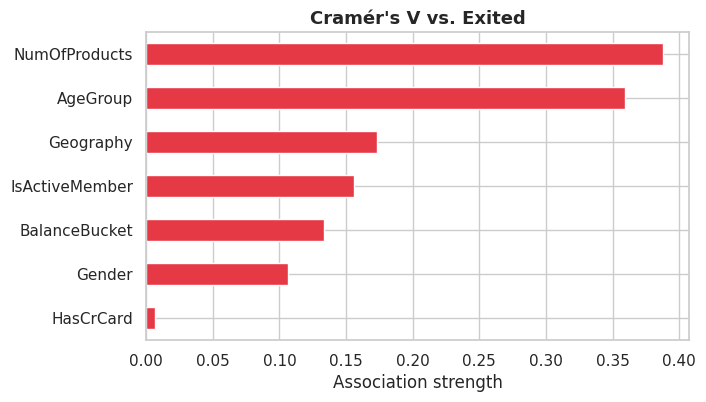

In [27]:
# 8.3 — Cramér's V *between each categorical and the churn target*
v_scores = pd.Series({c: cramers_v(df[c], df[TARGET_CLF]) for c in cat_features})
v_scores.sort_values().plot(kind="barh", color="#E63946", figsize=(7, 4))
plt.title("Cramér's V vs. Exited")
plt.xlabel("Association strength"); plt.show()


Inter-predictor correlations and Cramér's V are all moderate (< 0.5). There is **no multicollinearity** that would force us to drop variables — every feature can enter the model with its own coefficient.

---
## 9. Summary of insights

### For the classification track (`Exited`)

| Driver                                 | Evidence (tests)                   | Direction                          |
|----------------------------------------|------------------------------------|------------------------------------|
| Age (especially 45-60)                 | Mann-Whitney p ≪ 0.001             | older ⇒ more churn                 |
| Geography = Germany                    | χ² p ≪ 0.001, Cramér's V ≈ 0.17    | Germans churn ~2× more             |
| Gender = Female                        | χ² p ≪ 0.001                       | women churn ~1.5× more             |
| `NumOfProducts` ≥ 3                    | Mann-Whitney p ≪ 0.001             | huge spike in churn                |
| `IsActiveMember` = 0                   | χ² p ≪ 0.001, Cramér's V ≈ 0.16    | inactivity is a leading indicator  |
| Balance ≥ 100 k €                      | Mann-Whitney p ≪ 0.001             | high-balance customers churn more  |
| `HasCrCard`, `Tenure`, `EstimatedSalary` | p > 0.05                          | no useful signal                   |

These findings drive the engineered features used in `03_Classification.ipynb`:
`Is_HighRisk_Female`, `Germany_HighBalance`, `Has_ZeroBalance`, `Too_Many_Products`, `Inactive_MultiProduct`, `Balance_Salary_Ratio`, `Risk_Score`, and a KMeans `Profile` cluster.

### For the regression track (`EstimatedSalary`)

* The target is approximately **uniform** between 0 and 200 k €, not normal.
* **No numeric predictor** has |Pearson r| > 0.02 or |Spearman ρ| > 0.02.
* **No categorical predictor** is statistically associated (Kruskal p > 0.05, η² < 0.001).
* Therefore we expect any regression model to have an **R² close to 0** — a finding we will confirm in `02_Prediction.ipynb`.

